<a href="https://colab.research.google.com/github/AarjavShahh/ML_Repo/blob/main/CyberCrime_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("cybersecurity_large_synthesized_data.csv")
df.head()

,attack_type,target_system,outcome,timestamp,attacker_ip,target_ip,data_compromised_GB,attack_duration_min,security_tools_used,user_role,location,attack_severity,industry,response_time_min,mitigation_method
0,Phishing,Cloud Service,Failure,2024-04-03 11:13:15.083419,21.166.79.4,23.20.50.78,15.31,300,Firewall,Employee,Australia,2.0,Energy,164.0,Containment
1,DDoS,Email Server,Success,2024-02-03 20:51:56.083463,187.180.150.169,34.160.58.218,65.05,242,Endpoint Detection,Admin,Brazil,10.0,Retail,64.0,Reset Credentials
2,Zero-Day Exploit,Cloud Service,Success,2024-07-19 18:40:05.083472,57.161.159.140,213.142.125.206,48.99,120,Firewall,External User,Germany,7.0,Finance,87.0,Quarantine
3,SQL Injection,Email Server,Failure,2023-12-08 00:54:17.083478,207.108.16.104,4.104.193.49,16.29,286,MFA,Employee,Russia,3.0,Healthcare,23.0,Patch
4,Zero-Day Exploit,IoT Device,Failure,2024-07-23 05:38:20.083483,98.122.15.31,57.66.53.194,87.66,4,Firewall,Contractor,UK,6.0,Finance,129.0,Containment


1.   There are total 15 features of which 4 (data_compromised_GB, attack_duration_min, attack_severity, response_time_min) are "QUANTITATIVE DATA".

2.   Rest of them are "QUALITATIVE DATA".




In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21420 entries, 0 to 21419
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   attack_type          21420 non-null  object 
 1   target_system        21420 non-null  object 
 2   outcome              21420 non-null  object 
 3   timestamp            21420 non-null  object 
 4   attacker_ip          21420 non-null  object 
 5   target_ip            21420 non-null  object 
 6   data_compromised_GB  21420 non-null  float64
 7   attack_duration_min  21420 non-null  int64  
 8   security_tools_used  21420 non-null  object 
 9   user_role            21420 non-null  object 
 10  location             21419 non-null  object 
 11  attack_severity      21419 non-null  float64
 12  industry             21419 non-null  object 
 13  response_time_min    21419 non-null  float64
 14  mitigation_method    21419 non-null  object 
dtypes: float64(3), int64(1), object(11)


1. There are no null values in the dataset

In [ ]:
df.describe()

,data_compromised_GB,attack_duration_min,attack_severity,response_time_min
count,21420.000000,21420.000000,21419.000000,21419.000000
mean,49.964093,150.350934,5.523507,90.976703
std,28.827980,86.560756,2.863412,51.904664
min,0.000000,1.000000,1.000000,1.000000
25%,25.237500,75.000000,3.000000,46.000000
50%,49.955000,149.000000,6.000000,91.000000
75%,74.920000,226.000000,8.000000,136.000000
max,100.000000,300.000000,10.000000,180.000000


In [ ]:
print(df['data_compromised_GB'].sum())

1070230.8800000001


1. Maximum amount of data_compromised is 100 GB.
2. In total 5006258.56 GB of data in compromised.
3. Maximum amount of of attack_severnity is 10.
4. Maximum amount of response_time is 3 hrs.
5. Maximum amount of attack_duration is 300 min of 5 hrs.

In [ ]:
# Convert timestamp column to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Check for null values
print(df.isnull().sum())

# Drop duplicates if any
df = df.drop_duplicates()


attack_type            0
target_system          0
outcome                0
timestamp              0
attacker_ip            0
target_ip              0
data_compromised_GB    0
attack_duration_min    0
security_tools_used    0
user_role              0
location               1
attack_severity        1
industry               1
response_time_min      1
mitigation_method      1
dtype: int64


In [ ]:
df['attack_type'].unique()

array(['Phishing', 'DDoS', 'Zero-Day Exploit', 'SQL Injection', 'Malware',
       'Ransomware', 'Brute Force', 'Cross-Site Scripting'], dtype=object)

In [ ]:
att_ty = df['attack_type'].value_counts()
att_ty

,count
attack_type,
Zero-Day Exploit,2760
Brute Force,2744
Malware,2728
SQL Injection,2683
Ransomware,2662
DDoS,2646
Phishing,2605
Cross-Site Scripting,2592


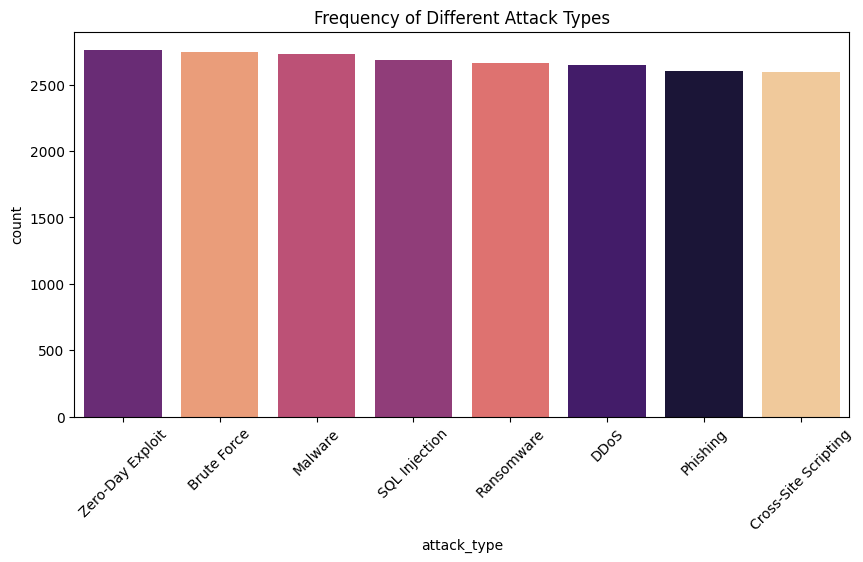

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='attack_type', order=df['attack_type'].value_counts().index, palette='magma', hue='attack_type', legend=False)
plt.title("Frequency of Different Attack Types")
plt.xticks(rotation=45)
plt.show()

* Shows which types of attacks (e.g., Phishing, DDoS, Malware) occur most often.

* The x-axis lists attack types
* The y-axis shows counts.

* High bars indicate the most common cyber attack methods — useful for prioritizing security resources

In [ ]:
df['target_system'].unique()

array(['Cloud Service', 'Email Server', 'IoT Device', 'User Account',
       'Network Switch', 'Web Server', 'Database', 'API'], dtype=object)

In [ ]:
tar_sys = df['target_system'].value_counts()
tar_sys

,count
target_system,
IoT Device,2712
Email Server,2699
Database,2692
Network Switch,2677
Web Server,2676
User Account,2671
Cloud Service,2666
API,2627


In [ ]:
df['target_system'].describe()

,target_system
count,21420
unique,8
top,IoT Device
freq,2712


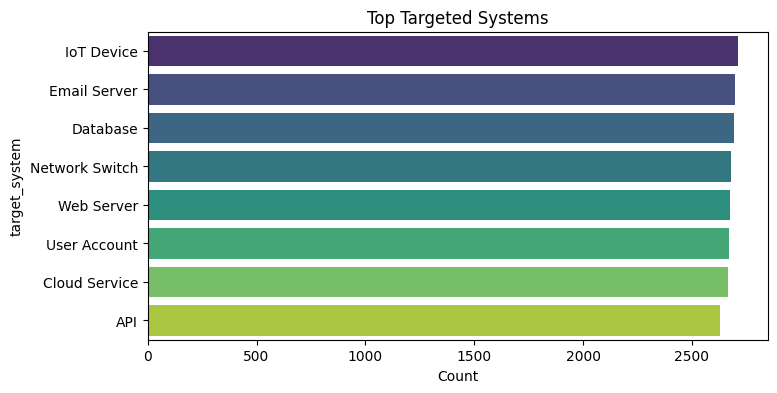

In [ ]:
top_targets = df['target_system'].value_counts().head(10)
plt.figure(figsize=(8,4))
sns.barplot(x=top_targets.values, y=top_targets.index, palette='viridis', hue=top_targets.index, legend=False)
plt.title("Top Targeted Systems")
plt.xlabel("Count")
plt.show()

* Shows which systems are most commonly attacked (e.g., Cloud, Email, Web Server).

* This helps focus hardening efforts on vulnerable systems.

In [ ]:
df['industry'].unique()

array(['Energy', 'Retail', 'Finance', 'Healthcare', 'Technology',
       'Education', 'Manufacturing', 'Government', nan], dtype=object)

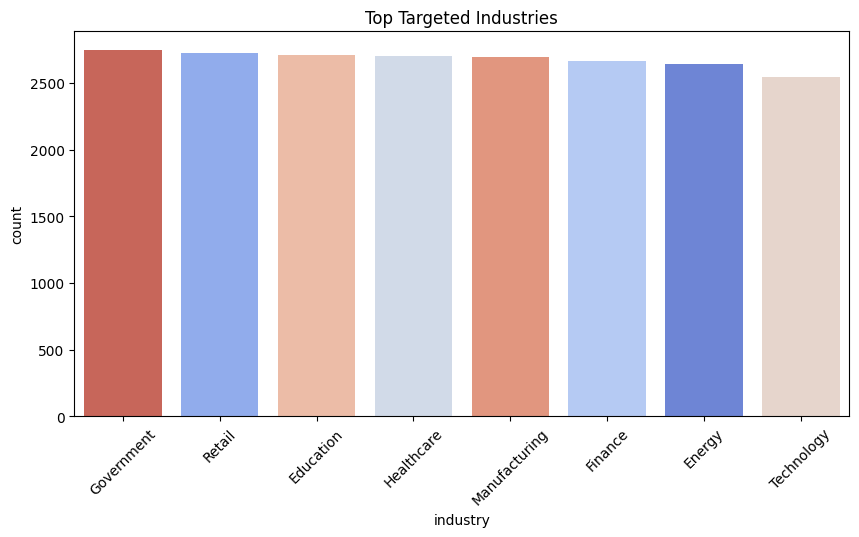

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='industry', order=df['industry'].value_counts().index, palette='coolwarm', hue='industry', legend=False)
plt.title("Top Targeted Industries")
plt.xticks(rotation=45)
plt.show()

* Identifies which sectors (Finance, Retail, Energy, etc.) experience the most attacks.

* Helps to spot which industrial sector is most vulnerable.

In [ ]:
df['mitigation_method'].unique()

array(['Containment', 'Reset Credentials', 'Quarantine', 'Patch',
       'Block IP', nan], dtype=object)

In [ ]:
df['mitigation_method'].value_counts()

,count
mitigation_method,
Patch,4337
Block IP,4336
Containment,4318
Reset Credentials,4238
Quarantine,4190


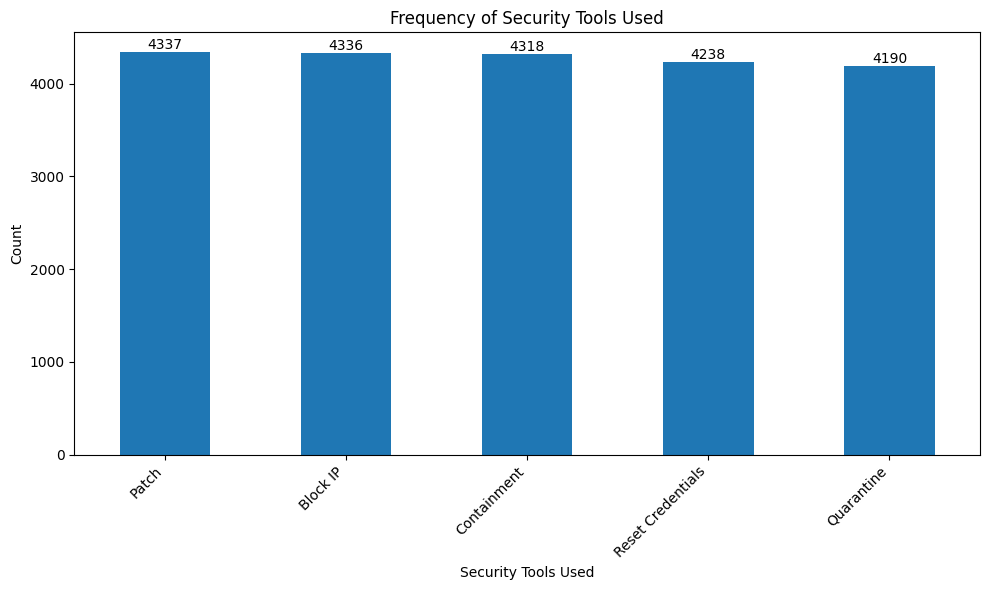

In [ ]:
sc_to = df['mitigation_method'].value_counts()

plt.figure(figsize=(10, 6))
ax = sc_to.plot(kind='bar')
plt.title('Frequency of Security Tools Used')
plt.xlabel('Security Tools Used')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

* Maximum number of attacks were mitigated using patch method
* Minimum number of attacks were mitigated using qurantine method

In [ ]:
total_outcome = df['outcome'].value_counts()

1. 50030 attacks are successful and 49970 attacks result failure.

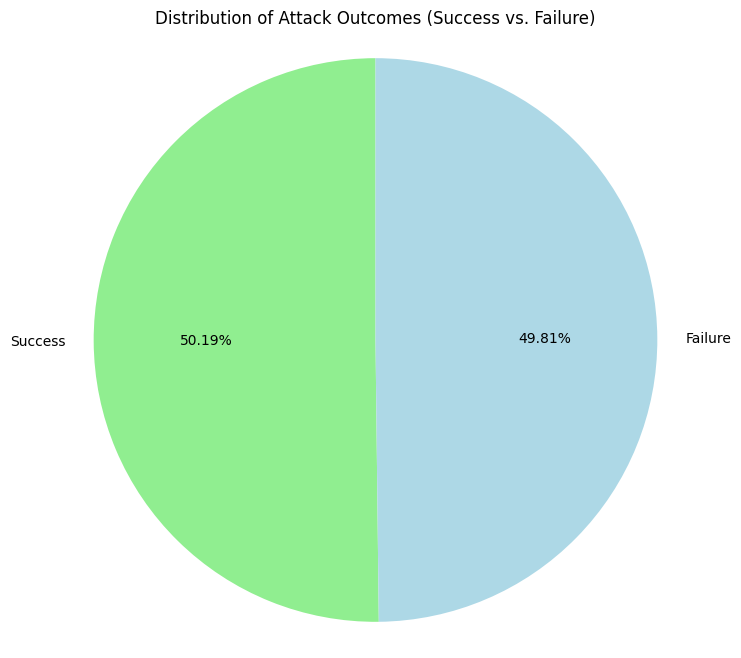

In [ ]:
outcome_counts = df['outcome'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(outcome_counts, labels=outcome_counts.index, autopct='%0.2f%%', startangle=90, colors=['lightgreen', 'lightblue'])
plt.title('Distribution of Attack Outcomes (Success vs. Failure)')
plt.axis('equal')
plt.show()

* The ratio of Success to Failure is near to 50:50.

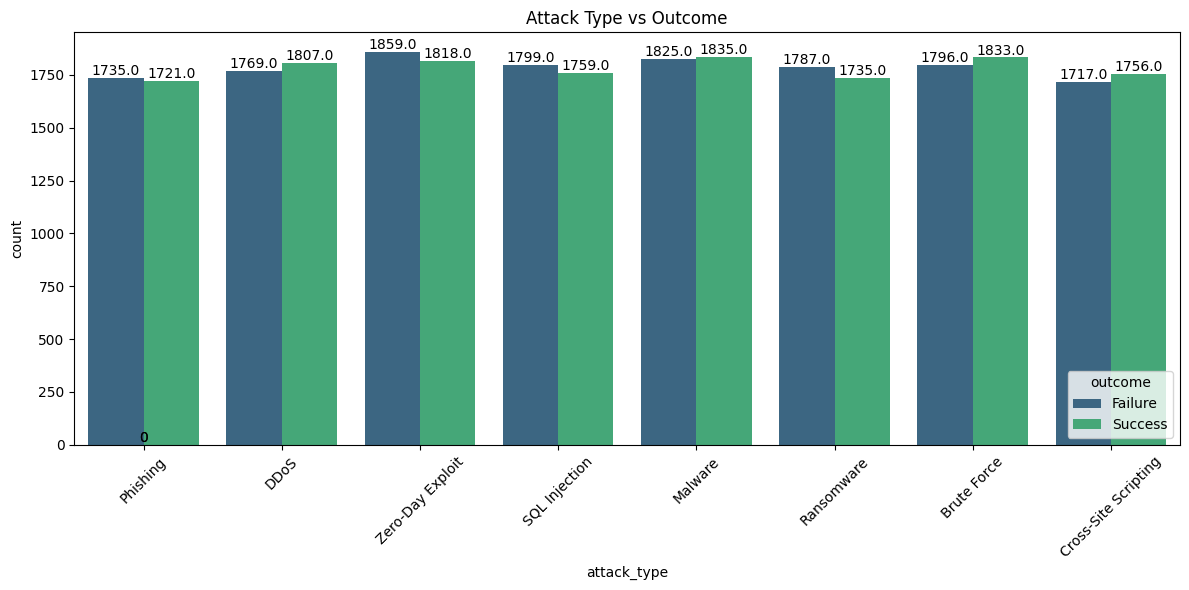

In [ ]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x='attack_type', hue='outcome', palette='viridis')
plt.title("Attack Type vs Outcome")
plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

* Compares how successful each type of attack is.

* If “Success” dominates for a certain attack type (say DDoS), that attack is harder to mitigate.

* Useful to identify weak points in security systems.

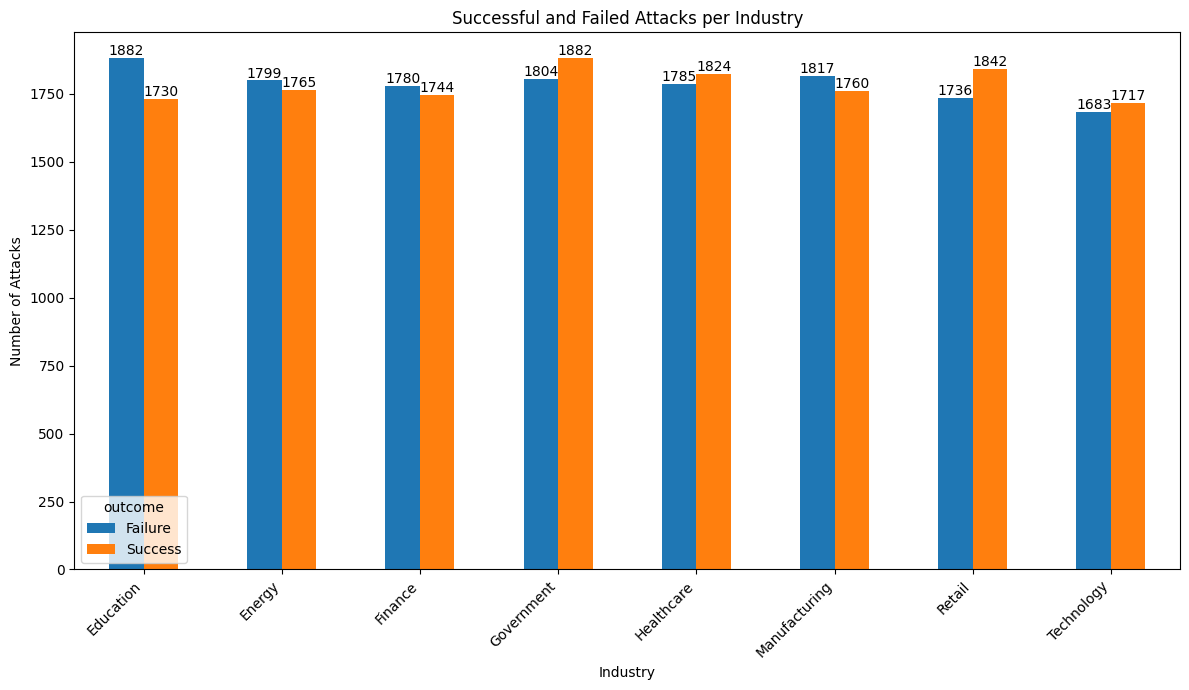

In [ ]:
df = pd.read_csv("cybersecurity_large_synthesized_data.csv")
industry_outcome_counts = df.groupby('industry')['outcome'].value_counts().unstack().fillna(0)
ax = industry_outcome_counts.plot(kind='bar', figsize=(12, 7))
plt.title('Successful and Failed Attacks per Industry')
plt.xlabel('Industry')
plt.ylabel('Number of Attacks')
plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

* Compares how many successful attack attempts were made on each industry.


In [ ]:
df['location'].unique()

array(['Australia', 'Brazil', 'Germany', 'Russia', 'UK', 'France', 'USA',
       'Canada', 'China', 'India', nan], dtype=object)

In [ ]:
loc = df['location'].value_counts()

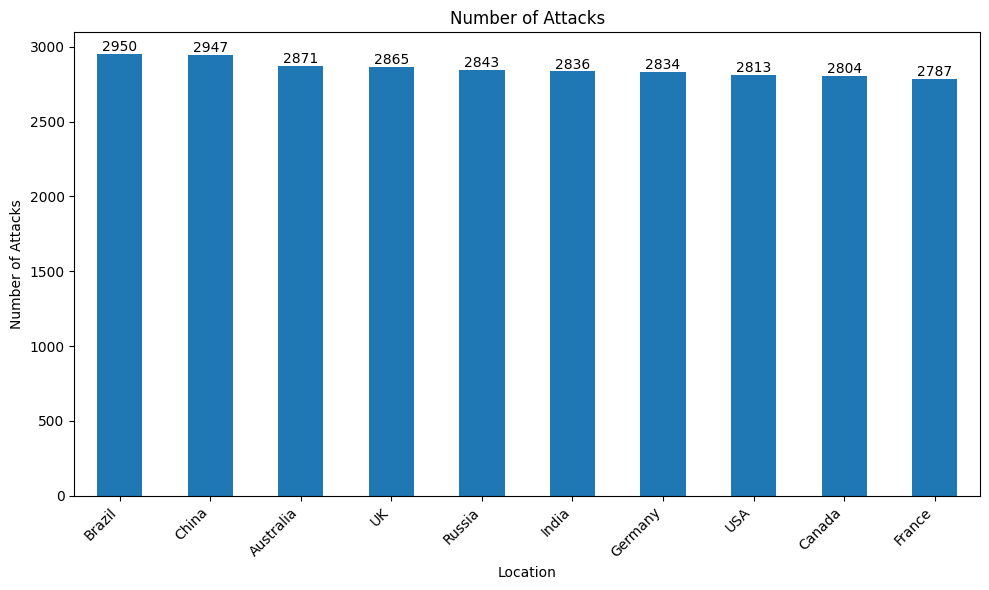

In [ ]:
plt.figure(figsize=(10, 6))
ax = loc.plot(kind='bar')
plt.title('Number of Attacks')
plt.xlabel('Location')
plt.ylabel('Number of Attacks')
plt.xticks(rotation=45, ha='right')

# Add values on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

* Hightest Cybercrime has occured in Brazil and lowest in India.

In [ ]:
df['security_tools_used'].unique()

array(['Firewall', 'Endpoint Detection', 'MFA', 'VPN', 'Antivirus', 'WAF',
       'SIEM', 'IDS', nan], dtype=object)

In [ ]:
sc_to = df['security_tools_used'].value_counts()
sc_to

,count
security_tools_used,
Endpoint Detection,3678
VPN,3615
SIEM,3584
IDS,3576
Antivirus,3558
WAF,3522
MFA,3515
Firewall,3502


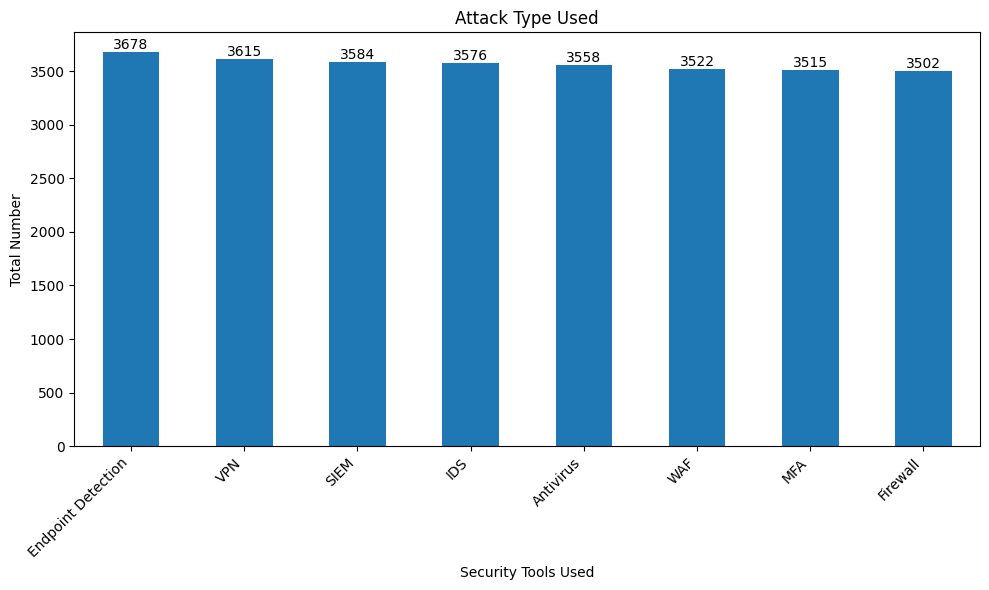

In [ ]:
plt.figure(figsize=(10, 6))
ax = sc_to.plot(kind='bar')
plt.title('Attack Type Used')
plt.xlabel('Security Tools Used')
plt.ylabel('Total Number')
plt.xticks(rotation=45, ha='right')

# Add values on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

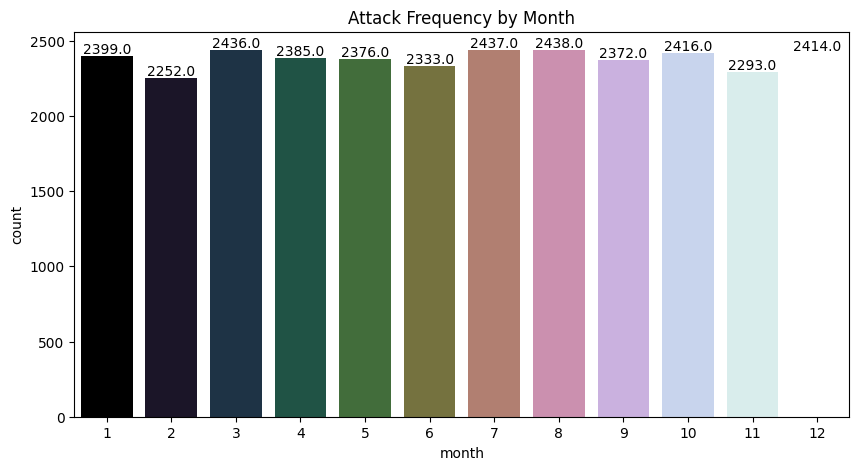

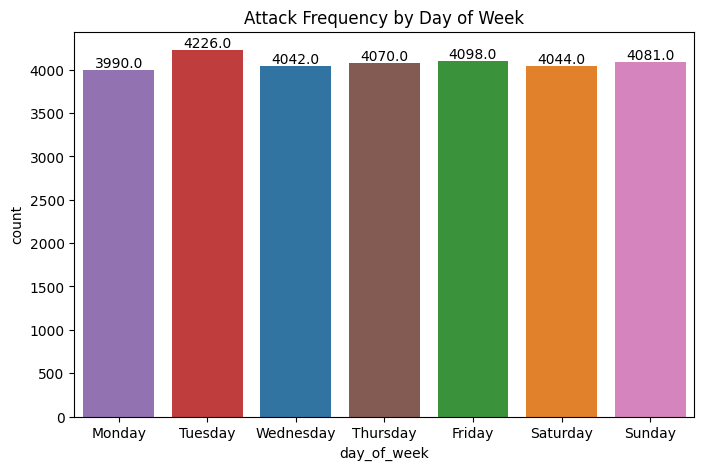

In [ ]:
# Convert timestamp column to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

df['month'] = df['timestamp'].dt.month
df['day_of_week'] = df['timestamp'].dt.day_name()

plt.figure(figsize=(10,5))
ax1 = sns.countplot(data=df, x='month', hue='month', palette='cubehelix', legend=False)
plt.title("Attack Frequency by Month")
for p in ax1.patches:
    ax1.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

plt.figure(figsize=(8,5))
ax2 = sns.countplot(data=df, x='day_of_week', hue='day_of_week', legend=False,
              order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title("Attack Frequency by Day of Week")
for p in ax2.patches:
    ax2.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

Shows when most attacks occur.

Helps identify time patterns — for example:

  * Peaks in Q4 → attacks around holidays (common).

  * More weekday activity → targeted business hours.

In [ ]:
df['attacker_ip'].describe()

,attacker_ip
count,28551
unique,28551
top,213.175.160.132
freq,1


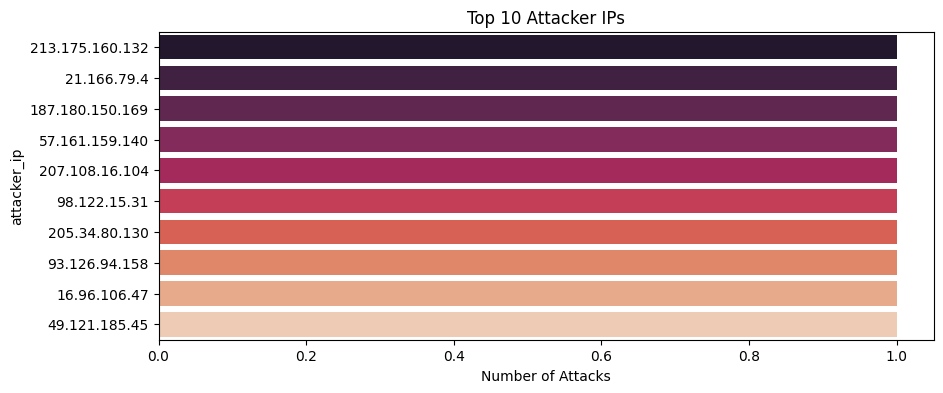

In [ ]:
top_attackers = df['attacker_ip'].value_counts().head(10)
plt.figure(figsize=(10,4))
sns.barplot(x=top_attackers.values, y=top_attackers.index, palette='rocket', hue=top_attackers.index, legend=False)
plt.title("Top 10 Attacker IPs")
plt.xlabel("Number of Attacks")
plt.show()

* Highlights the IPs most frequently associated with attacks.


**Summary**

1. Most frequent attacks: DDoS and Phishing dominate.

2. Most targeted industries: Retail, Finance, and Energy sectors.

3. Most targeted industries: Retail, Finance, and Energy sectors.

4. Data compromise correlation: Longer attacks often leak more data.

5. Severity vs. response time: Quicker response = lower severity.

6. Attack timing: Peak activity during business hours or specific months.

7. Top sources: A few attacker IPs account for many incidents — likely automated bots.
